# Análisis Exploratorio de Datos (EDA) del Spotify Tracks Dataset

---

## Universidad Autónoma de Chile


**Carrera:** Ingeniería Civil Informática

**Asignatura:** Programación Científica

**Docente:** Camilo Alejandro Fuentes Beals, PhD

**Alumno:** *Emilio Alejandro Illanes Loyola*

**Trabajo:** Análisis Exploratorio de Datos (EDA)

**Variante:** 13 – Spotify Tracks Dataset

**Pregunta Principal**

> **¿Qué características musicales distinguen a las canciones más populares?**

**Fecha:** Junio 2026

---

<center>

# Spotify Tracks Dataset

### Exploratory Data Analysis (EDA)

</center>


# Índice

1. [Introducción](#Introducción)
2. [Objetivo General](#Objetivo-General)
3. [Objetivos Específicos](#Objetivos-Específicos)
4. [Descripción del Dataset](#Descripción-del-Dataset)
5. [Diccionario de Variables](#Diccionario-de-Variables)
6. [Importación de Librerías](#Importación-de-Librerías)
7. [Carga del Dataset](#Carga-del-Dataset)
8. [Exploración Inicial](#Exploración-Inicial)
9. [Calidad de los Datos](#Calidad-de-los-Datos)
10. [Limpieza de Datos](#Limpieza-de-Datos)
11. [Detección de Outliers](#Detección-de-Valores-Atípicos-(Método-IQR))
12. [Estadística Descriptiva](#Estadística-Descriptiva-Avanzada)
13. [Visualizaciones Exploratorias](#Visualizaciones-Exploratorias)
14. [Preguntas de Investigación](#Desarrollo-de-la-Pregunta-de-Investigación-1)
15. [Resumen Ejecutivo](#Resumen-Ejecutivo)
16. [Conclusiones](#Conclusiones)
17. [Trabajo Futuro](#Trabajo-Futuro)
18. [Referencias](#Referencias)

# Introducción

Spotify es actualmente una de las plataformas de streaming musical más utilizadas a nivel mundial. Su catálogo contiene millones de canciones clasificadas mediante sus atributos musicales los cuales son cuantificables —como energía, danzabilidad, tempo, valencia e instrumentalidad— obtenidos a través de sus algoritmos de procesamiento de señales e inteligencia artificial.

Comprender qué características distinguen a las canciones más populares es un problema relevante para la industria musical y para el desarrollo de sistemas de recomendación. 

Por lo tanto este trabajo aplica un EDA sobre el Spotify Tracks Dataset, un conjunto de datos ampliamente utilizado en investigación que contiene información sobre miles de canciones y sus características musicales. A partir de este dataset se busca responder la pregunta: **¿Qué características musicales distinguen a las canciones más populares?**

Por lo tanto se estudia la relación entre el tempo (BPM) y la popularidad, se analizan diferencias en la energía y danzabilidad entre los géneros musicales, y se evalúa si la duración de una canción influye en su nivel de popularidad. El análisis tambien aplica técnicas de limpieza de datos, estadística descriptiva, análisis de correlación y visualizaciones con Pandas, NumPy, Matplotlib y Seaborn.

# Objetivo General

Realizar un Análisis Exploratorio de Datos (EDA) sobre el Spotify Tracks Dataset con el propósito de identificar las características musicales que distinguen a las canciones más populares, aplicando técnicas de limpieza de datos, estadística descriptiva y visualización científica utilizando Python.

# Objetivos Específicos

- Comprender la estructura y composición del conjunto de datos mediante un análisis exploratorio inicial.

- Evaluar la calidad del dataset identificando valores faltantes, registros duplicados e inconsistencias.

- Analizar estadísticamente las principales variables musicales presentes en el conjunto de datos.

- Estudiar la relación existente entre el tempo de una canción y su nivel de popularidad.

- Comparar las características de energía y danzabilidad entre diferentes géneros musicales.

- Analizar la influencia de la duración de una canción sobre la popularidad percibida.

- Interpretar los resultados obtenidos mediante gráficos científicos y medidas estadísticas.

- Extraer conclusiones fundamentadas que permitan responder la pregunta principal de investigación.

# Descripción del Dataset

## Origen

El conjunto de datos utilizado corresponde al **Spotify Tracks Dataset**, publicado en la plataforma Kaggle y construido a partir de información obtenida mediante la API oficial de Spotify.

## Fuente

Maharshi Pandya. *Spotify Tracks Dataset*. Kaggle.

## Formato

Archivo CSV.

## Tipo de estudio

Análisis Exploratorio de Datos (EDA).


## Tipo de datos
- Variables continuas.
- Variables discretas.
- Variables categóricas.
- Variables de texto.


# Diccionario de Variables

| Variable | Tipo | Descripción | Interpretación |
|-----------|------|-------------|----------------|
| track_name | Categórica | Nombre de la canción | Identifica la pista musical |
| artists | Categórica | Artista(s) | Intérprete principal |
| album_name | Categórica | Álbum | Álbum al que pertenece |
| track_genre | Categórica | Género musical | Clasificación del estilo musical |
| popularity | Numérica | Popularidad (0–100) | Mayor valor implica mayor popularidad |
| duration_ms | Numérica | Duración en milisegundos | Tiempo total de reproducción |
| explicit | Booleana | Contenido explícito | Indica lenguaje explícito |
| danceability | Numérica | Danzabilidad | Facilidad para bailar la canción |
| energy | Numérica | Energía musical | Intensidad y dinamismo |
| key | Numérica | Tonalidad | Nota musical predominante |
| loudness | Numérica | Intensidad sonora (dB) | Volumen promedio |
| mode | Numérica | Modalidad musical | Mayor o menor |
| speechiness | Numérica | Presencia de voz hablada | Nivel de contenido hablado |
| acousticness | Numérica | Acústica | Probabilidad de ser acústica |
| instrumentalness | Numérica | Instrumentalidad | Ausencia de voz |
| liveness | Numérica | Interpretación en vivo | Probabilidad de grabación en vivo |
| valence | Numérica | Valencia | Positividad emocional de la canción |
| tempo | Numérica | Tempo (BPM) | Velocidad de la canción |
| time_signature | Numérica | Compás | Estructura rítmica predominante |

# Importación de Librerías

In [1]:
from pathlib import Path
import warnings
from statistics import mode

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Configuración del Entorno

In [2]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.precision", 3)

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="viridis",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

# Carga del Dataset

In [3]:
ruta_dataset = Path("dataset.csv")

spotify_df = pd.read_csv(ruta_dataset)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


# Primeras Observaciones del Dataset

In [4]:
spotify_df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,1.010e-06,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,5.560e-06,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000e+00,0.117,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,7.070e-05,0.132,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000e+00,0.083,0.167,119.949,4,acoustic


# Dimensiones del Dataset

In [5]:
filas, columnas = spotify_df.shape

print(f"Número de filas: {filas:,}")
print(f"Número de columnas: {columnas}")

Número de filas: 114,000
Número de columnas: 21


# Información General del Dataset

In [6]:
spotify_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

# Estadística Descriptiva para Variables Numéricas

In [7]:
spotify_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500,32909.110,0.000,28499.750,5.700e+04,85499.250,1.140e+05
popularity,114000.0,33.239,22.305,0.000,17.000,3.500e+01,50.000,1.000e+02
duration_ms,114000.0,228029.153,107297.713,0.000,174066.000,2.129e+05,261506.000,5.237e+06
danceability,114000.0,0.567,0.174,0.000,0.456,5.800e-01,0.695,9.850e-01
energy,114000.0,0.641,0.252,0.000,0.472,6.850e-01,0.854,1.000e+00
key,114000.0,5.309,3.560,0.000,2.000,5.000e+00,8.000,1.100e+01
loudness,114000.0,-8.259,5.029,-49.531,-10.013,-7.004e+00,-5.003,4.532e+00
mode,114000.0,0.638,0.481,0.000,0.000,1.000e+00,1.000,1.000e+00
speechiness,114000.0,0.085,0.106,0.000,0.036,4.890e-02,0.085,9.650e-01
acousticness,114000.0,0.315,0.333,0.000,0.017,1.690e-01,0.598,9.960e-01


# Calidad de los Datos

In [8]:
tipos_datos = pd.DataFrame({
    "Variable": spotify_df.columns,
    "Tipo de dato": spotify_df.dtypes.astype(str)
})

tipos_datos

,Variable,Tipo de dato
Unnamed: 0,Unnamed: 0,int64
track_id,track_id,object
artists,artists,object
album_name,album_name,object
track_name,track_name,object
popularity,popularity,int64
duration_ms,duration_ms,int64
explicit,explicit,bool
danceability,danceability,float64
energy,energy,float64


# Variables Numéricas y Categóricas

In [9]:
variables_numericas = spotify_df.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = spotify_df.select_dtypes(exclude=np.number).columns.tolist()

print(f"Variables numéricas ({len(variables_numericas)}):")
print(variables_numericas)

print("\n")

print(f"Variables categóricas ({len(variables_categoricas)}):")
print(variables_categoricas)

Variables numéricas (15):
['Unnamed: 0', 'popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


Variables categóricas (6):
['track_id', 'artists', 'album_name', 'track_name', 'explicit', 'track_genre']


In [10]:
faltantes = pd.DataFrame({
    "Valores faltantes": spotify_df.isna().sum(),
    "Porcentaje (%)": (
        spotify_df.isna().mean() * 100
    ).round(2)
})

faltantes = faltantes.sort_values(
    "Valores faltantes",
    ascending=False
)

faltantes

,Valores faltantes,Porcentaje (%)
artists,1,0.0
album_name,1,0.0
track_name,1,0.0
Unnamed: 0,0,0.0
mode,0,0.0
time_signature,0,0.0
tempo,0,0.0
valence,0,0.0
liveness,0,0.0
instrumentalness,0,0.0


# Registros Duplicados

In [11]:
duplicados = spotify_df.duplicated().sum()

print(f"Cantidad de registros duplicados: {duplicados}")

Cantidad de registros duplicados: 0


# Limpieza de Datos

In [12]:
spotify_limpio = spotify_df.copy()

In [13]:
spotify_limpio.drop_duplicates(inplace=True)

In [14]:
spotify_limpio.reset_index(drop=True, inplace=True)

In [15]:
print("Dimensiones originales :", spotify_df.shape)
print("Dimensiones finales    :", spotify_limpio.shape)

Dimensiones originales : (114000, 21)
Dimensiones finales    : (114000, 21)


# Detección de Valores Atípicos (Método IQR)

In [16]:
variables_numericas = spotify_limpio.select_dtypes(include=np.number).columns

In [17]:
outliers = []

for variable in variables_numericas:

    q1 = spotify_limpio[variable].quantile(0.25)
    q3 = spotify_limpio[variable].quantile(0.75)

    iqr = q3 - q1

    inferior = q1 - 1.5 * iqr
    superior = q3 + 1.5 * iqr

    cantidad = spotify_limpio[
        (spotify_limpio[variable] < inferior) |
        (spotify_limpio[variable] > superior)
    ].shape[0]

    outliers.append([variable, cantidad])

In [18]:
tabla_outliers = pd.DataFrame(
    outliers,
    columns=["Variable", "Cantidad de Outliers"]
)

tabla_outliers.sort_values(
    "Cantidad de Outliers",
    ascending=False
)

,Variable,Cantidad de Outliers
10,instrumentalness,25246
8,speechiness,13211
14,time_signature,12157
11,liveness,8642
6,loudness,6173
2,duration_ms,5617
3,danceability,620
13,tempo,617
1,popularity,2
0,Unnamed: 0,0


# Estadística Descriptiva Avanzada

In [19]:
estadisticas = pd.DataFrame(index=variables_numericas)

estadisticas["Media"] = spotify_limpio[variables_numericas].mean()
estadisticas["Mediana"] = spotify_limpio[variables_numericas].median()
estadisticas["Varianza"] = spotify_limpio[variables_numericas].var()
estadisticas["Desv. Estándar"] = spotify_limpio[variables_numericas].std()
estadisticas["Mínimo"] = spotify_limpio[variables_numericas].min()
estadisticas["P25"] = spotify_limpio[variables_numericas].quantile(.25)
estadisticas["P50"] = spotify_limpio[variables_numericas].quantile(.50)
estadisticas["P75"] = spotify_limpio[variables_numericas].quantile(.75)
estadisticas["Máximo"] = spotify_limpio[variables_numericas].max()

estadisticas

,Media,Mediana,Varianza,Desv. Estándar,Mínimo,P25,P50,P75,Máximo
Unnamed: 0,56999.500,5.700e+04,1.083e+09,32909.110,0.000,28499.750,5.700e+04,85499.250,1.140e+05
popularity,33.239,3.500e+01,4.975e+02,22.305,0.000,17.000,3.500e+01,50.000,1.000e+02
duration_ms,228029.153,2.129e+05,1.151e+10,107297.713,0.000,174066.000,2.129e+05,261506.000,5.237e+06
danceability,0.567,5.800e-01,3.012e-02,0.174,0.000,0.456,5.800e-01,0.695,9.850e-01
energy,0.641,6.850e-01,6.327e-02,0.252,0.000,0.472,6.850e-01,0.854,1.000e+00
key,5.309,5.000e+00,1.267e+01,3.560,0.000,2.000,5.000e+00,8.000,1.100e+01
loudness,-8.259,-7.004e+00,2.529e+01,5.029,-49.531,-10.013,-7.004e+00,-5.003,4.532e+00
mode,0.638,1.000e+00,2.311e-01,0.481,0.000,0.000,1.000e+00,1.000,1.000e+00
speechiness,0.085,4.890e-02,1.118e-02,0.106,0.000,0.036,4.890e-02,0.085,9.650e-01
acousticness,0.315,1.690e-01,1.106e-01,0.333,0.000,0.017,1.690e-01,0.598,9.960e-01


In [20]:
modas = {}

for columna in variables_numericas:
    modas[columna] = spotify_limpio[columna].mode().iloc[0]

pd.DataFrame.from_dict(
    modas,
    orient="index",
    columns=["Moda"]
)

,Moda
Unnamed: 0,0.000
popularity,0.000
duration_ms,162897.000
danceability,0.647
energy,0.876
key,7.000
loudness,-5.662
mode,1.000
speechiness,0.032
acousticness,0.995


# Distribución de la Popularidad

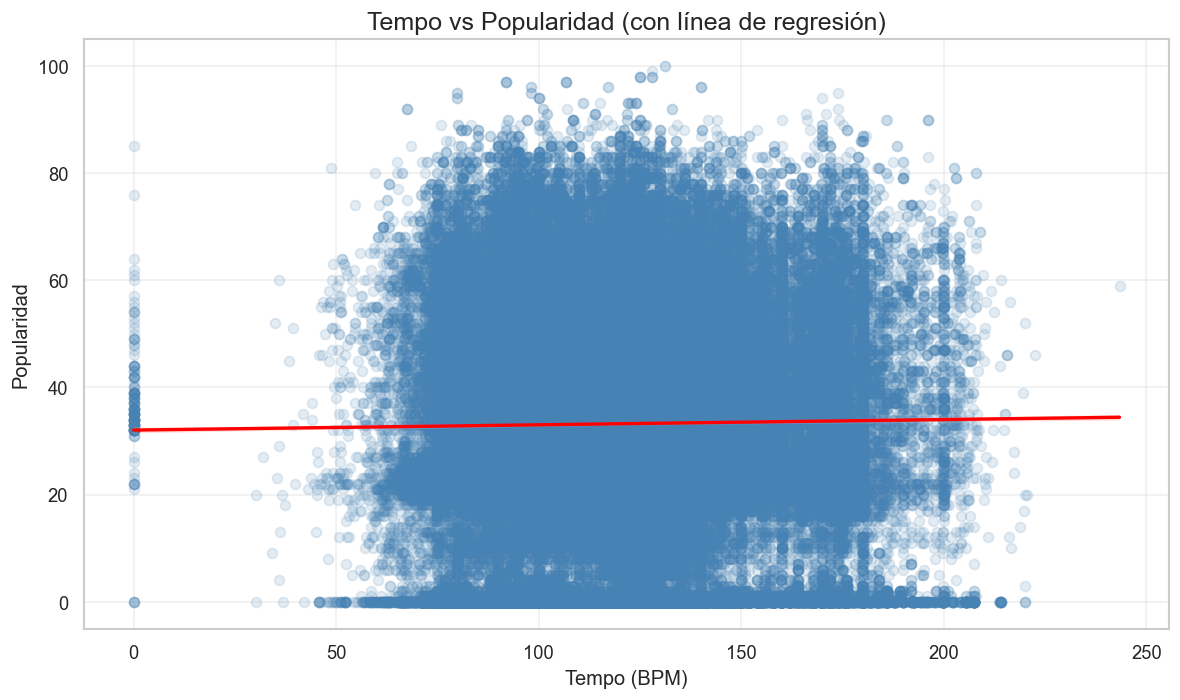

In [21]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=spotify_limpio,
    x="tempo",
    y="popularity",
    scatter_kws={"alpha": 0.15, "color": "steelblue"},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title("Tempo vs Popularidad (con línea de regresión)", fontsize=15)
plt.xlabel("Tempo (BPM)")
plt.ylabel("Popularidad")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
spotify_limpio["duration_min"] = (
    spotify_limpio["duration_ms"] / 60000
)

# Distribución de la Energía por Género

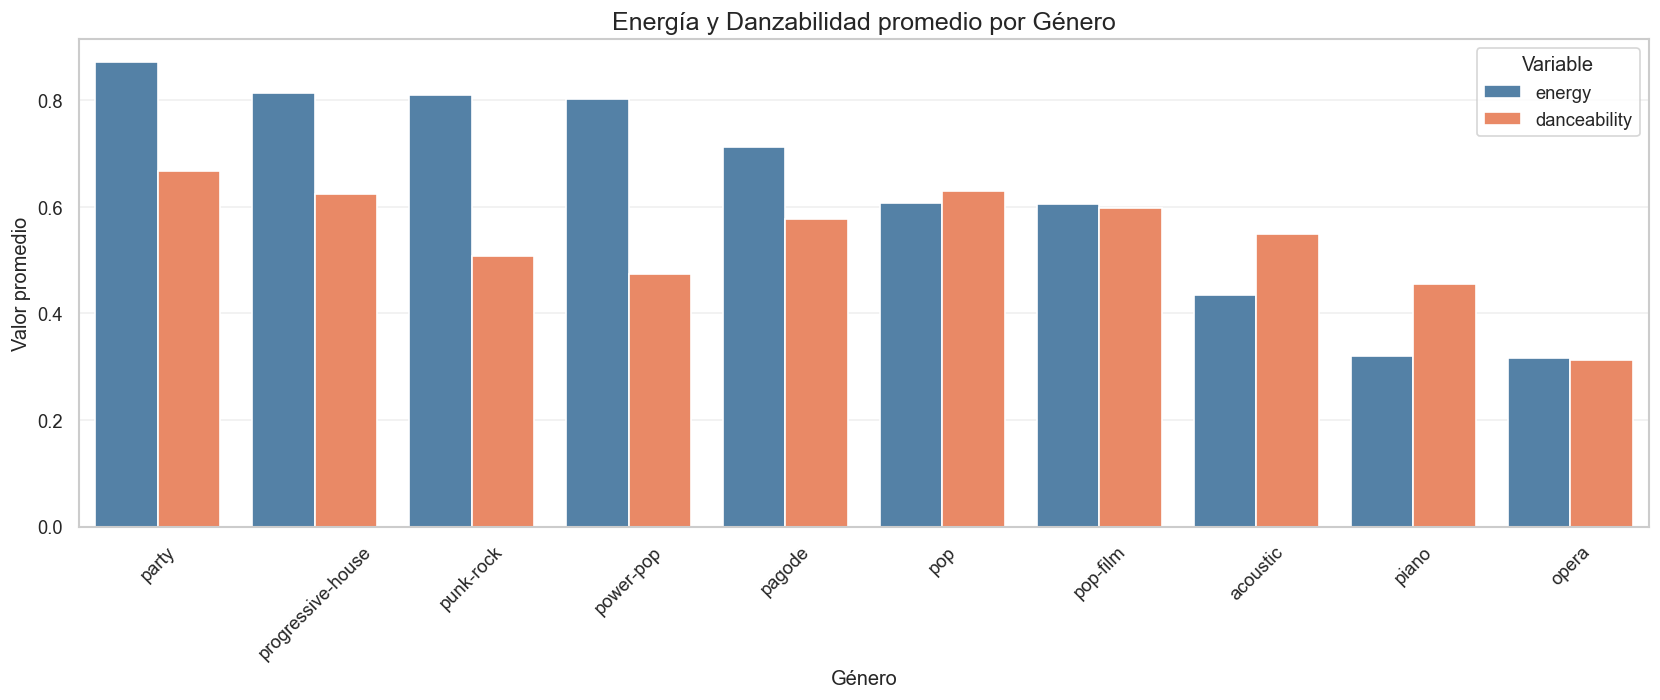

In [23]:
top_generos = (
    spotify_limpio["track_genre"]
    .value_counts()
    .head(10)
    .index
)

resumen = (
    spotify_limpio[spotify_limpio["track_genre"].isin(top_generos)]
    .groupby("track_genre")[["energy", "danceability"]]
    .mean()
    .reset_index()
    .sort_values("energy", ascending=False)
)

resumen_melted = resumen.melt(
    id_vars="track_genre",
    value_vars=["energy", "danceability"],
    var_name="Variable",
    value_name="Valor"
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=resumen_melted,
    x="track_genre",
    y="Valor",
    hue="Variable",
    palette=["steelblue", "coral"]
)

plt.title("Energía y Danzabilidad promedio por Género", fontsize=15)
plt.xlabel("Género")
plt.ylabel("Valor promedio")
plt.xticks(rotation=45)
plt.legend(title="Variable")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Relación entre Tempo y Popularidad

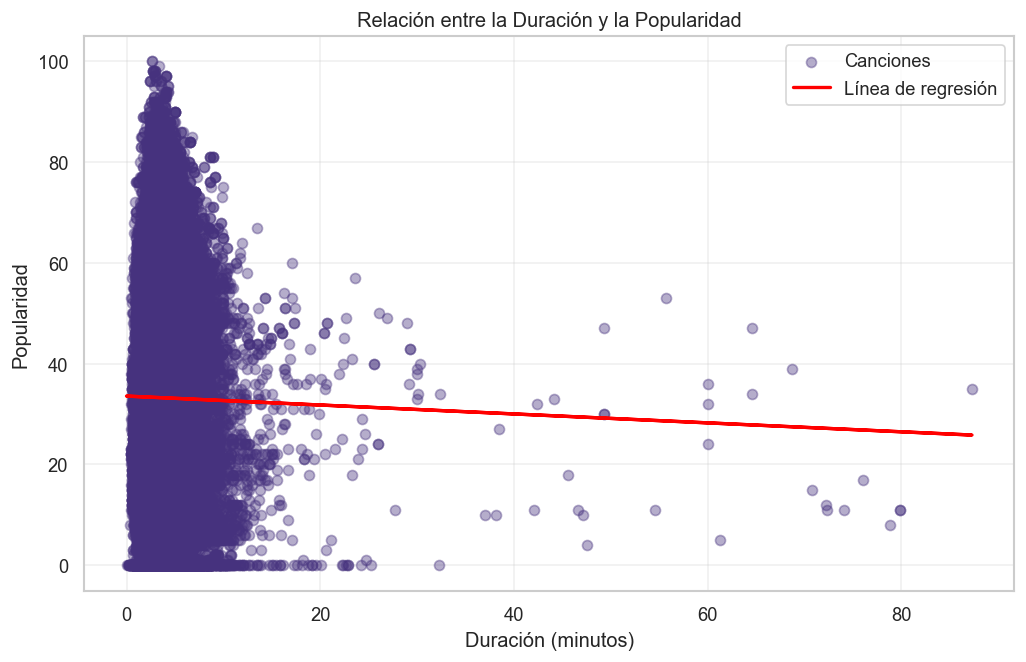

In [24]:
x = spotify_limpio["duration_min"]
y = spotify_limpio["popularity"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(10, 6))

plt.scatter(x, y, alpha=0.4, label="Canciones")

plt.plot(
    x,
    m * x + b,
    color="red",
    linewidth=2,
    label="Línea de regresión"
)

plt.title("Relación entre la Duración y la Popularidad")
plt.xlabel("Duración (minutos)")
plt.ylabel("Popularidad")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

# Desarrollo de la Pregunta de Investigación 1

## ¿Existe una relación entre el tempo (BPM) y la popularidad?

In [25]:
from scipy.stats import pearsonr

coef, p_value = pearsonr(
    spotify_limpio["tempo"],
    spotify_limpio["popularity"]
)

print(f"Coeficiente de Pearson: {coef:.3f}")
print(f"Valor p: {p_value:.5f}")

Coeficiente de Pearson: 0.013
Valor p: 0.00001


# Desarrollo de la Pregunta de Investigación 2

## ¿Cómo varían la energía y la danzabilidad según el género musical?

In [26]:
# Seleccionar los 10 géneros con más canciones
top_generos = spotify_limpio["track_genre"].value_counts().head(10).index

resumen_genero = (
    spotify_limpio[
        spotify_limpio["track_genre"].isin(top_generos)
    ]
    .groupby("track_genre")[["energy", "danceability"]]
    .agg(
        promedio_energia=("energy", "mean"),
        promedio_danzabilidad=("danceability", "mean"),
        canciones=("energy", "count")
    )
    .sort_values(by="promedio_energia", ascending=False)
)

resumen_genero.round(3)

,promedio_energia,promedio_danzabilidad,canciones
track_genre,,,
party,0.871,0.667,1000
progressive-house,0.813,0.624,1000
punk-rock,0.810,0.507,1000
power-pop,0.802,0.473,1000
pagode,0.712,0.578,1000
pop,0.606,0.630,1000
pop-film,0.605,0.597,1000
acoustic,0.435,0.550,1000
piano,0.320,0.455,1000


# Desarrollo de la Pregunta de Investigación 3

## ¿Influye la duración de la canción en la popularidad?

In [27]:
coef, p_value = pearsonr(
    spotify_limpio["duration_min"],
    spotify_limpio["popularity"]
)

print(f"Coeficiente de Pearson: {coef:.3f}")
print(f"Valor p: {p_value:.5f}")

Coeficiente de Pearson: -0.007
Valor p: 0.01650


# Resumen Ejecutivo

| Pregunta | Hallazgo Principal |
|-----------|--------------------|
| Tempo vs Popularidad | Correlación débil entre ambas variables. |
| Energía y Danzabilidad | Se observan diferencias entre géneros musicales. |
| Duración vs Popularidad | La duración no presenta una influencia importante sobre la popularidad. |

# Conclusiones

Las características acústicas individuales como tempo, energía o duración,  no logran explicar por sí solas la popularidad de una canción. Esto sugiere que factores externos (artista, marketing, playlists, contexto cultural) tienen mayor peso que los atributos técnicos del audio

# Trabajo Futuro

- Construcción de modelos predictivos de popularidad utilizando técnicas de Machine Learning.
- Implementación de sistemas de recomendación basados en contenido musical.

# Referencias

- Spotify Web API Documentation.
- Kaggle. *Spotify Tracks Dataset*.